In [2]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib

#plt.style.use('ggplot')
#ggplot is R based visualisation package that provides better graphics with higher level of abstraction

## **EDA**

In [3]:
import pandas as pd
data = pd.read_csv("../Data/pima_diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [17]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
data.duplicated().sum()

0

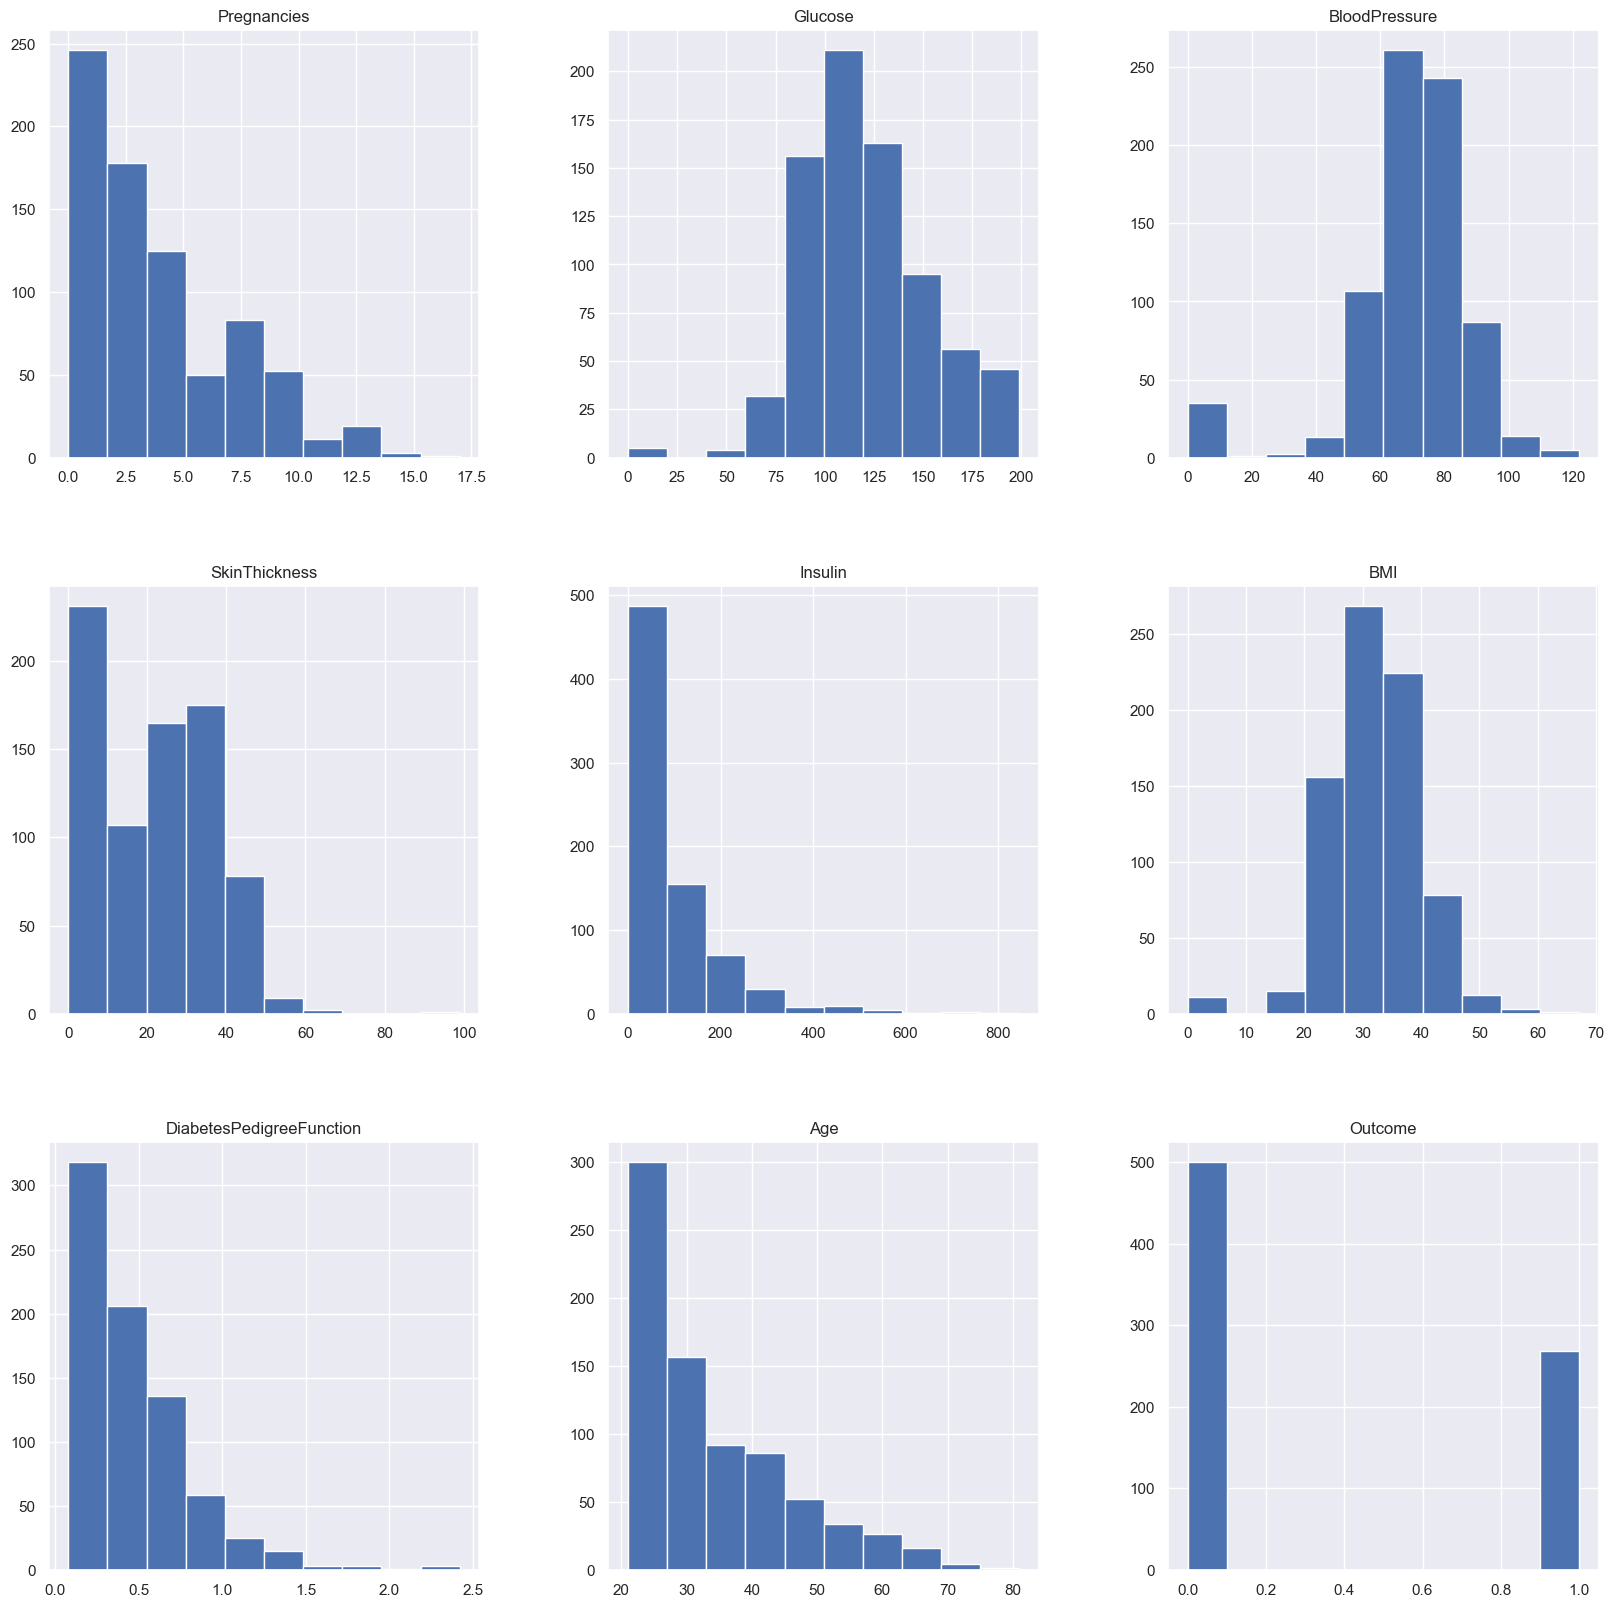

In [19]:
data.hist(figsize=(20,20))
plt.show()

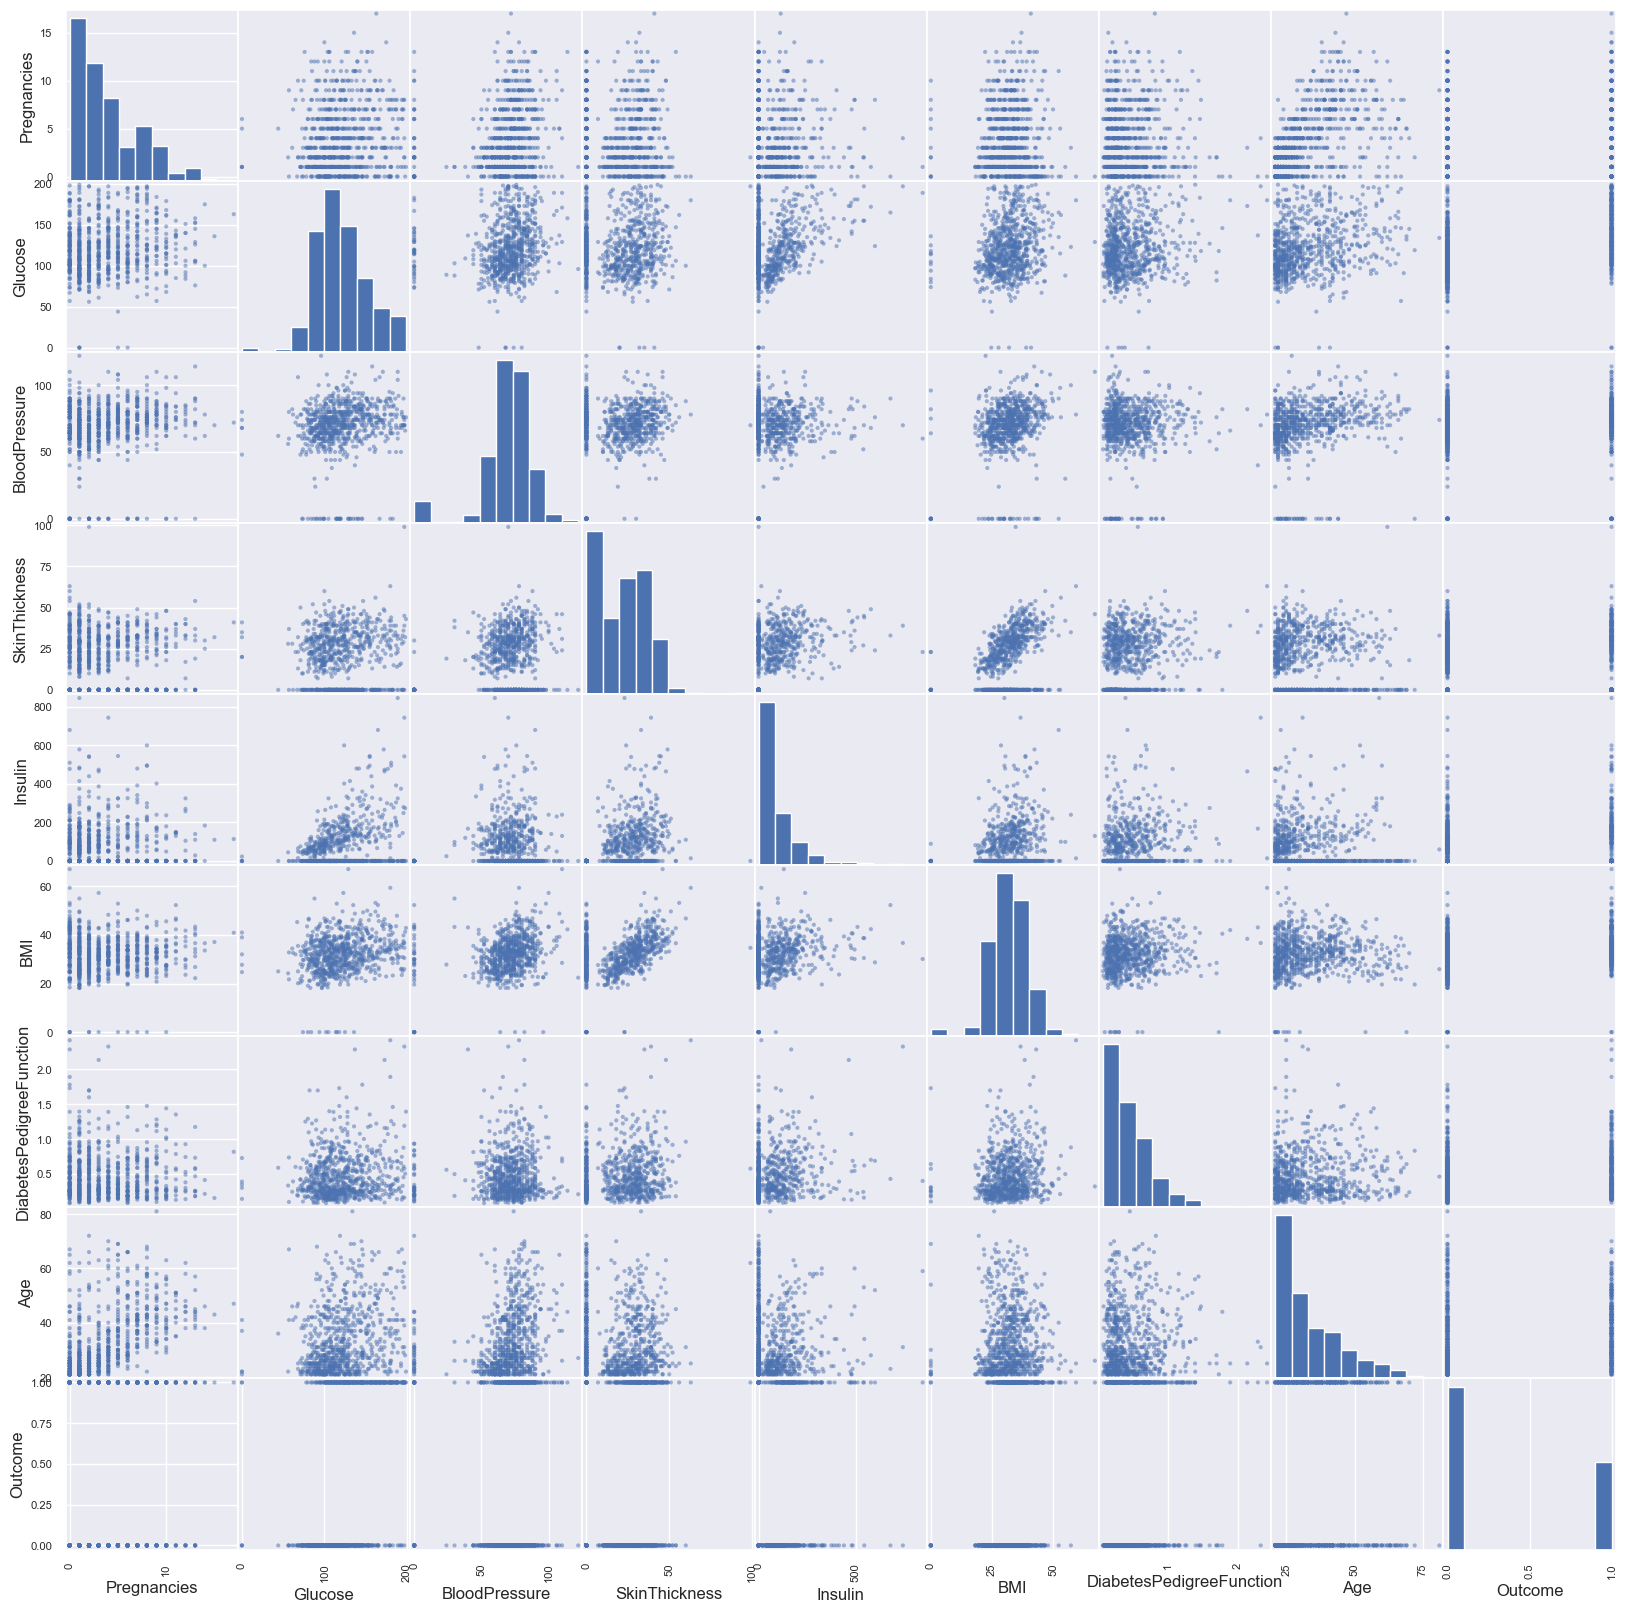

In [18]:
from pandas.plotting import scatter_matrix
p = scatter_matrix(data, figsize=(20,20))

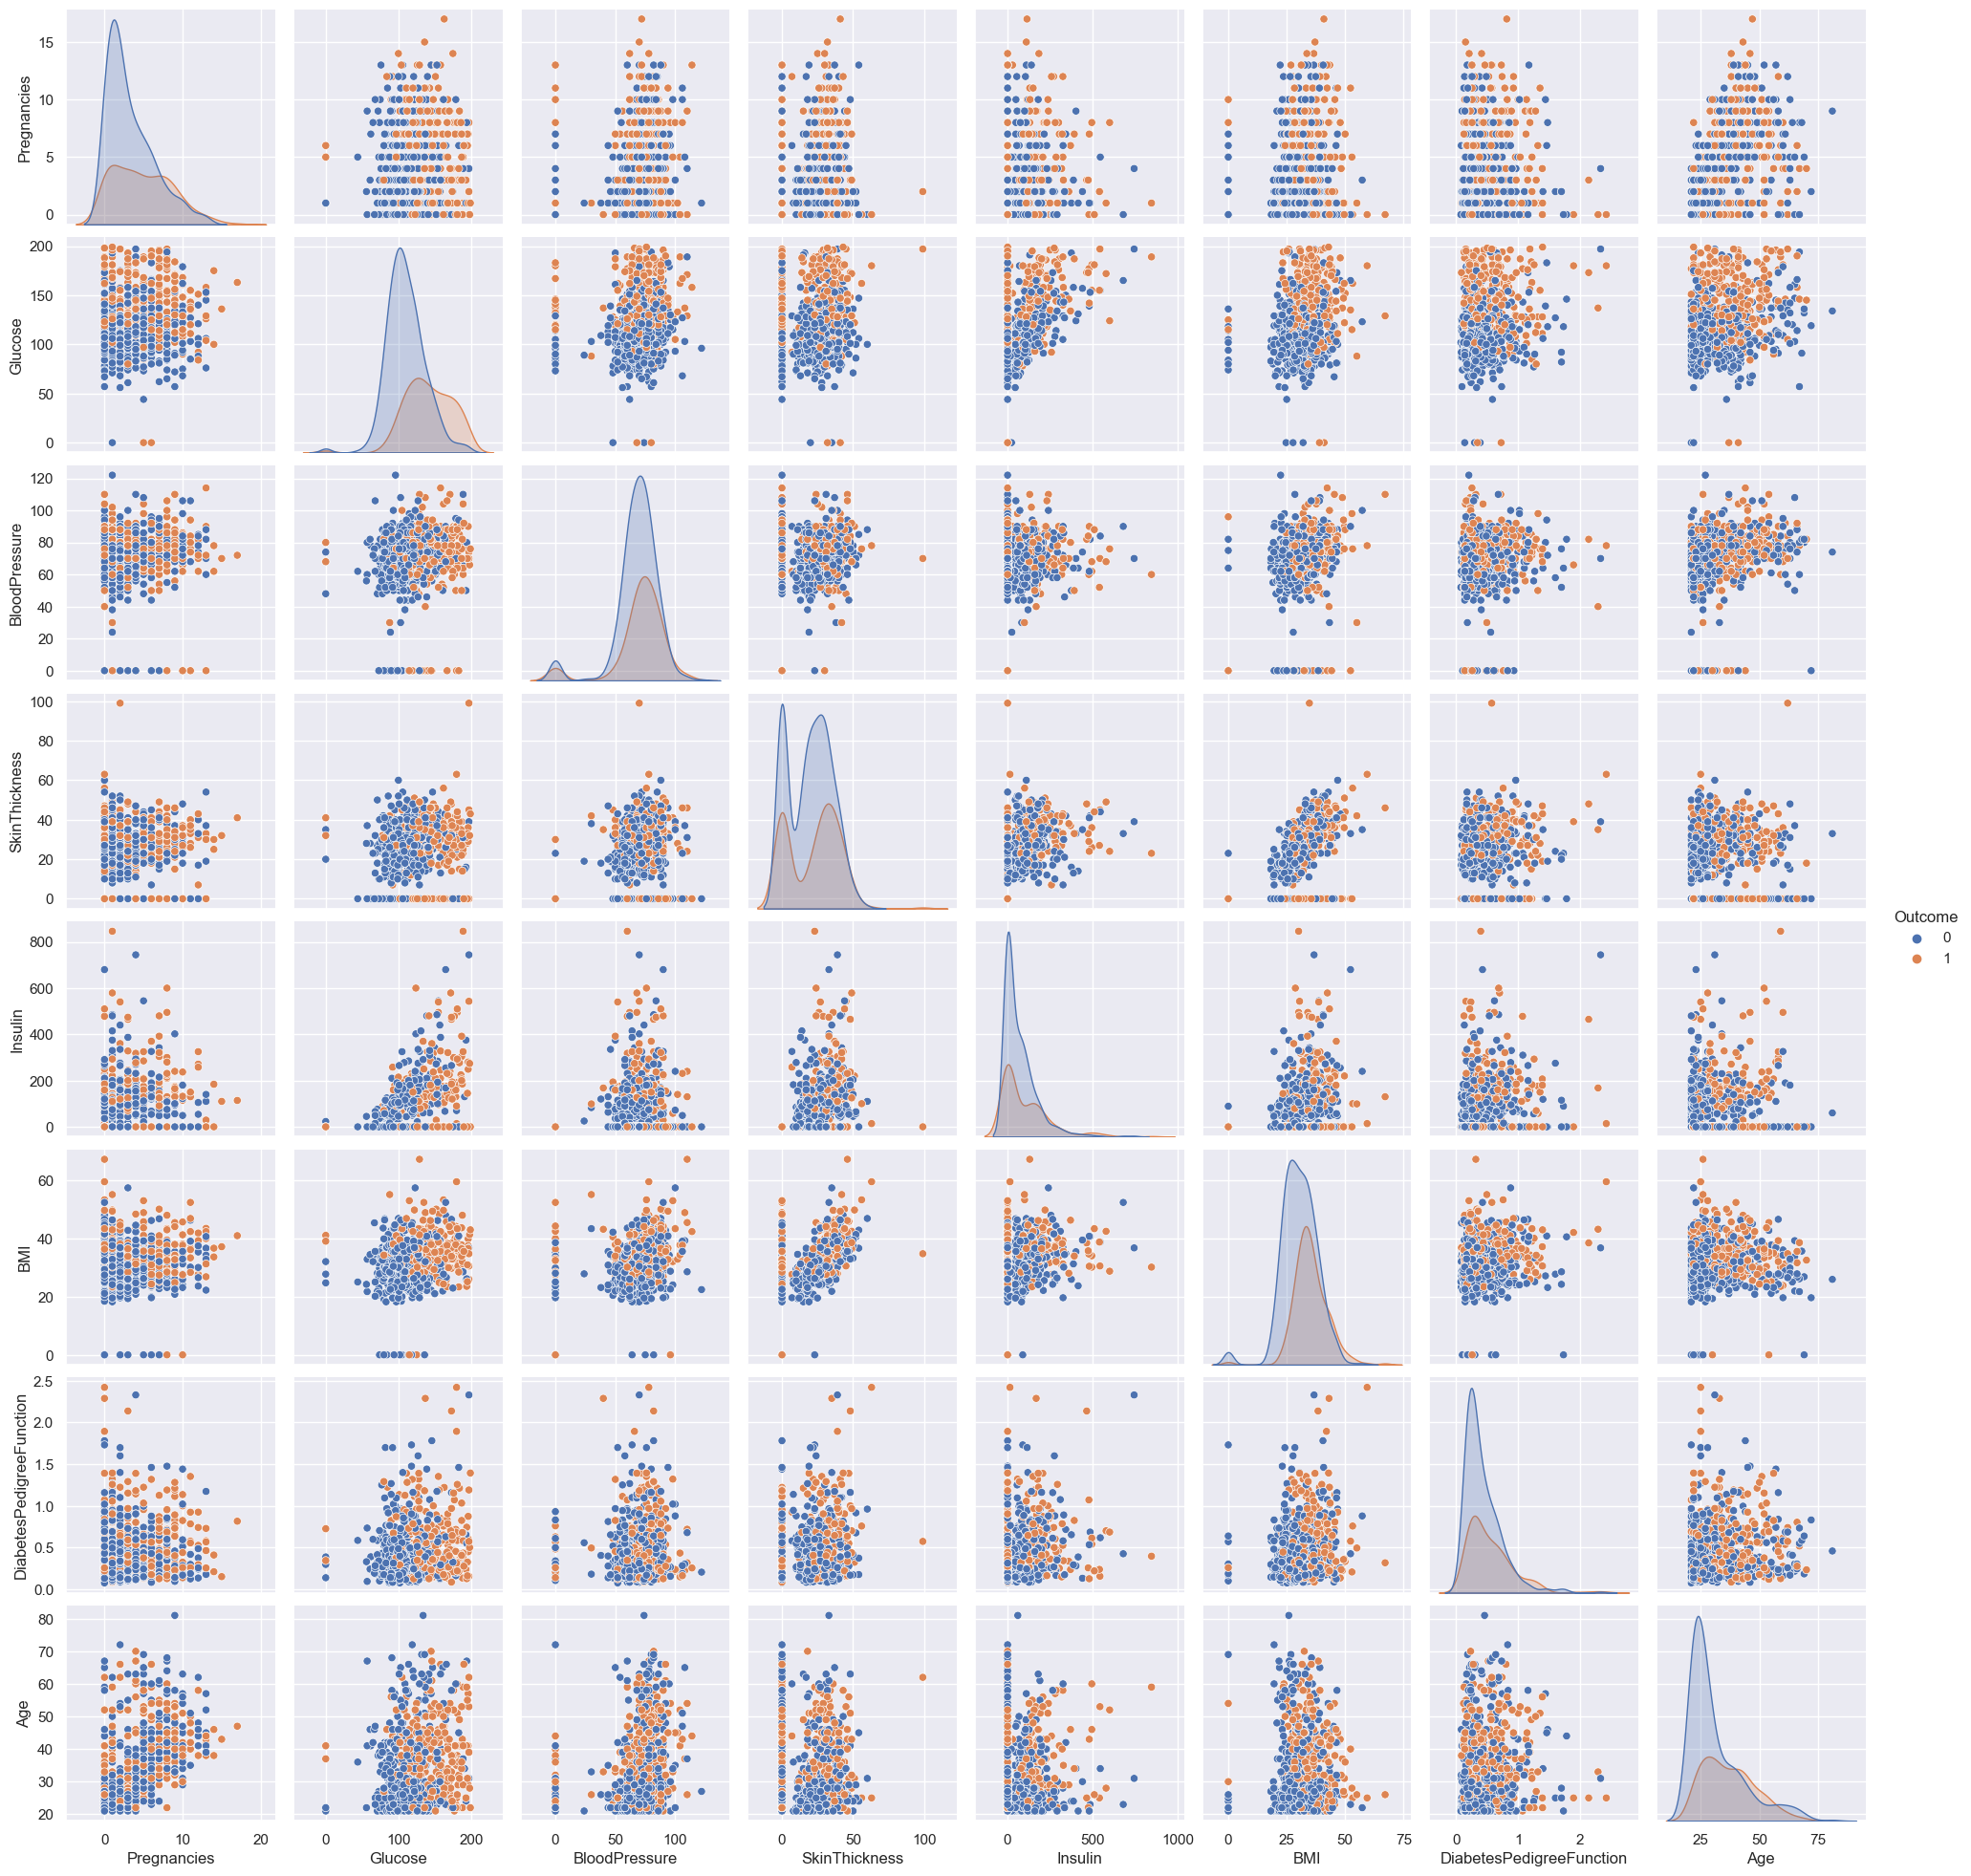

In [20]:
p=sns.pairplot(data, hue = 'Outcome')

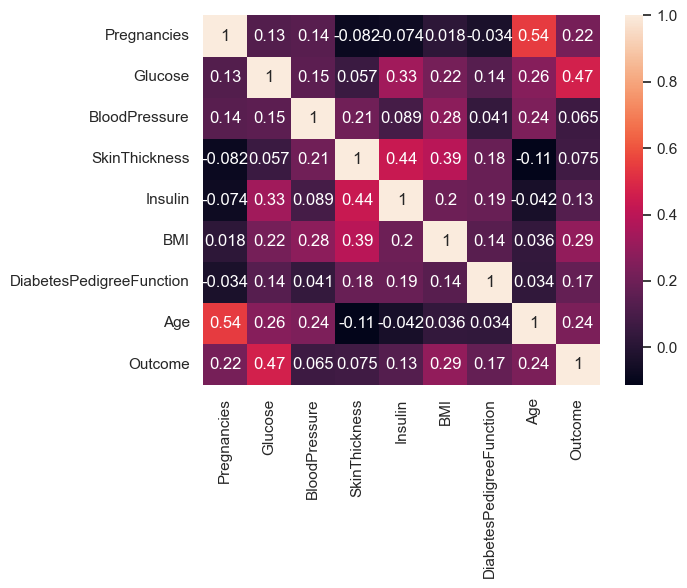

In [21]:
p=sns.heatmap(data.corr(),annot=True)

### Scaling Data

In [4]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()

X =  pd.DataFrame(sc_X.fit_transform(data.drop(["Outcome"],axis = 1),),
        columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])
y = data.Outcome

In [22]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


In [23]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [39]:
joblib.dump(sc_X, 'Output_Model/scaler_dm.pkl')

['Output_Model/scaler_dm.pkl']

<Axes: xlabel='Outcome', ylabel='Count'>

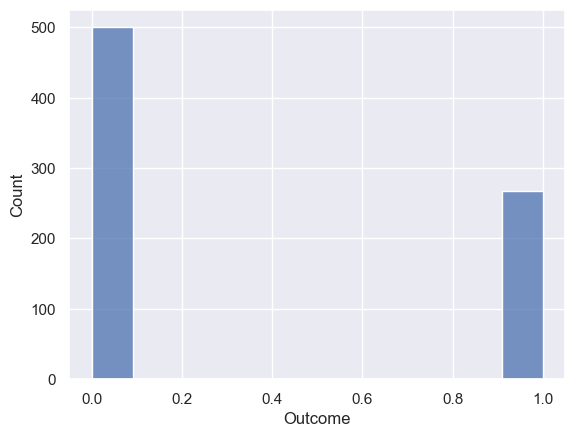

In [24]:
sns.histplot(data['Outcome'])

In [5]:
#importing train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

## MODELLING dengan SMOTE

In [26]:
# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Initialize SMOTE for oversampling
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize the XGBoost classifier
xg = XGBClassifier(n_estimators=350)

# Fit the model using resampled data
xg.fit(X_train_resampled, y_train_resampled)

# Make predictions
xg_preds = xg.predict(X_test)

# Print classification report
print(classification_report(y_test, xg_preds))


              precision    recall  f1-score   support

           0       0.82      0.75      0.78       100
           1       0.60      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



<Axes: xlabel='Outcome', ylabel='Count'>

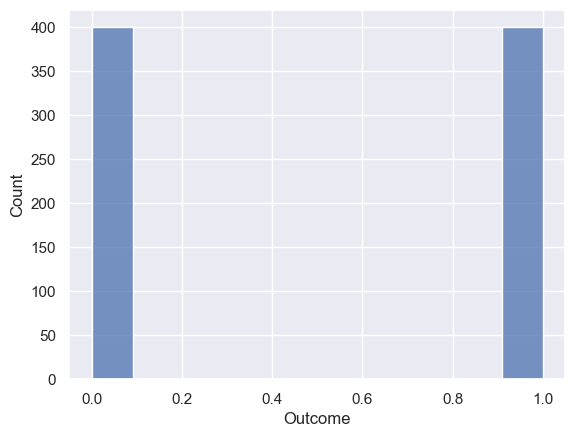

In [27]:
sns.histplot(y_train_resampled)

In [ ]:
# Menghitung dan menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, xg_preds)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix for nfold ')
plt.show()

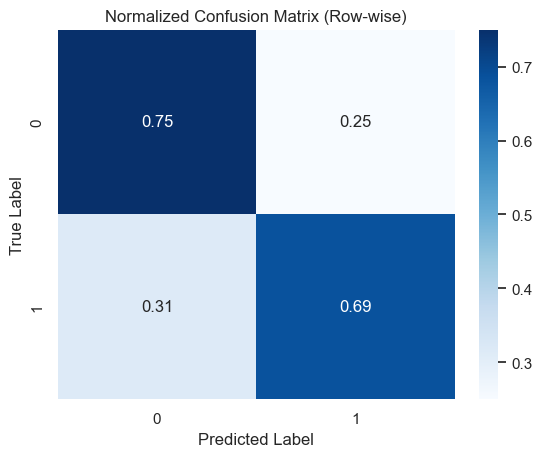

In [14]:
##Membuat confussion matrix yang dinormalisasi
def normalize_confusion_matrix(cm, norm='true'):
    if norm == 'true':
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif norm == 'pred':
        cm_normalized = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
    elif norm == 'all':
        cm_normalized = cm.astype('float') / cm.sum()
    else:
        raise ValueError("Unknown normalization type. Use 'true', 'pred', or 'all'.")
    
    return cm_normalized

cm = confusion_matrix(y_test, xg_preds)
cm_normalized = normalize_confusion_matrix(cm, norm='true')

# Plotting
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
plt.title('Normalized Confusion Matrix (Row-wise)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## MODELLING Menggunakan Weight

In [6]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()

In [7]:
X =  pd.DataFrame(sc_X.fit_transform(data.drop(["Outcome"],axis = 1),),
        columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])
y = data.Outcome

In [29]:
joblib.dump(sc_X, "./Output_Model/scaler_dm.pkl")

['./Output_Model/scaler_dm.pkl']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

In [10]:
ratio

1.8691588785046729

In [11]:
import xgboost as xgb
xg = xgb.XGBClassifier(n_estimators = 100, scale_pos_weight=ratio)
xg.fit(X_train, y_train)
xg_preds= xg.predict(X_test)
print(classification_report(y_test, xg_preds))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       100
           1       0.63      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [12]:
import xgboost as xgb
from xgboost import DMatrix

# Inisialisasi data dan parameter
params = {
    "objective": "binary:logistic",
    "colsample_bytree": 0.3,
    "learning_rate": 0.1,
    "max_depth": 10,
    "alpha": 10,
    "scale_pos_weight": ratio  # Pastikan 'ratio' telah didefinisikan
}

# Membuat DMatrix untuk XGBoost
data_dmatrix = xgb.DMatrix(data=X_train, label=y_train)  # Ganti X_train dan y_train sesuai data Anda

# List untuk menyimpan hasil dari masing-masing nfold
nfolds = [3, 5, 10]
best_results = {}

for n in nfolds:
    # Menjalankan cross-validation untuk setiap nilai nfold
    xgb_cv = xgb.cv(
        dtrain=data_dmatrix,
        params=params,
        nfold=n,
        num_boost_round=50,  # Jumlah iterasi yang digunakan selama cross-validation
        early_stopping_rounds=10,
        metrics="auc",
        as_pandas=True,
        seed=42,
    )
    
    # Menyimpan iterasi terbaik berdasarkan AUC
    best_iteration = xgb_cv['test-auc-mean'].idxmax()
    best_auc = xgb_cv['test-auc-mean'].iloc[best_iteration]
    
    # Menyimpan hasil terbaik berdasarkan AUC
    best_results[n] = {
        'best_iteration': best_iteration,
        'best_auc': best_auc,
        'xgb_cv': xgb_cv
    }
    
    print(f"nfold = {n}")
    print(f"Best AUC: {best_auc} at iteration {best_iteration}")
    print("="*50)

# Menentukan nfold dengan AUC terbaik
best_nfold = max(best_results, key=lambda x: best_results[x]['best_auc'])
print(f"nfold terbaik berdasarkan AUC adalah: {best_nfold} dengan AUC {best_results[best_nfold]['best_auc']}")


nfold = 3
Best AUC: 0.8298684640252306 at iteration 49
nfold = 5
Best AUC: 0.8209903096054919 at iteration 35
nfold = 10
Best AUC: 0.816640630257402 at iteration 9
nfold terbaik berdasarkan AUC adalah: 3 dengan AUC 0.8298684640252306


In [13]:
# Membuat model terbaik berdasarkan nfold terbaik dan iterasi terbaik
best_iteration = best_results[best_nfold]['best_iteration']
params['n_estimators'] = best_iteration  # Set n_estimators ke iterasi terbaik

In [14]:
# Latih model dengan data pelatihan
model_best = xgb.XGBClassifier(**params)
model_best.fit(X_train, y_train)

XGBClassifier(alpha=10, base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.3,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=10, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=49, n_jobs=0,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=10, ...)

In [15]:
# Prediksi data uji
y_pred_best = model_best.predict(X_test)
print(classification_report(y_test, y_pred_best ))

              precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



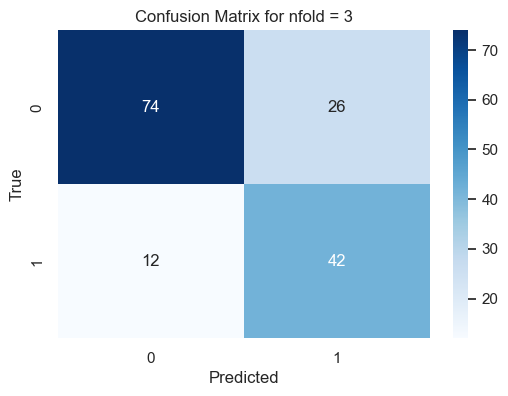

In [12]:
from sklearn.metrics import confusion_matrix

# Menghitung dan menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix for nfold = {best_nfold}')
plt.show()

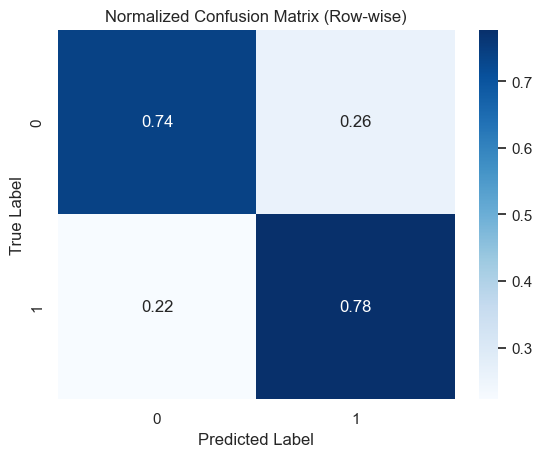

In [13]:
##Membuat confussion matrix yang dinormalisasi
def normalize_confusion_matrix(cm, norm='true'):
    if norm == 'true':
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif norm == 'pred':
        cm_normalized = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
    elif norm == 'all':
        cm_normalized = cm.astype('float') / cm.sum()
    else:
        raise ValueError("Unknown normalization type. Use 'true', 'pred', or 'all'.")
    
    return cm_normalized

cm = confusion_matrix(y_test, y_pred_best)
cm_normalized = normalize_confusion_matrix(cm, norm='true')

# Plotting
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
plt.title('Normalized Confusion Matrix (Row-wise)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Ekspor MODEL

In [24]:
import joblib

# Tentukan path dan nama file untuk menyimpan model
model_path = "./Output_Model/pima_diabetes.pkl"
# Simpan model
joblib.dump(model_best, model_path)
print(f"Model saved to {model_path}")


Model saved to ./Output_Model/pima_diabetes.pkl


### Coba gunakan model

In [15]:
model = "./Output_Model/pima_diabetes.joblib"

In [6]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Memuat model yang disimpan (sesuaikan nama file model)
model_path = "./Output_Model/pima_diabetes.pkl" # Sesuaikan path model
model = joblib.load(model_path)

# Memuat data test tanpa kolom Y
data_test = pd.read_csv(r"D:\Lomba-Lomba\TSDN 2024\App\sampled_data_2.csv")

sc_X = StandardScaler()
data_test = (sc_X.fit_transform(data_test))

In [7]:
# Melakukan prediksi
predictions = model.predict(data_test)

# Menampilkan atau menyimpan hasil prediksi
print(predictions)
pd.DataFrame(predictions, columns=['Predictions']).to_csv("predictions.csv", index=False)
print("Prediksi telah disimpan ke predictions.csv")

[1 0 0 0 1 1 0 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 1 0 0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0 1 1
 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0
 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0
 0 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0
 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0
 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1
 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1 0
 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0
 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0
 0 1 1 0 1 1 0 1 1 0 1 0 

c:\Users\HAJRAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

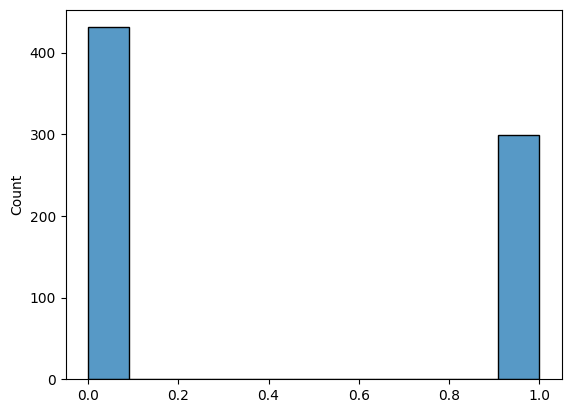

In [9]:
import seaborn as sns
sns.histplot(predictions)

In [ ]:
# Menyimpan hasil prediksi ke file CSV
pd.DataFrame(predictions, columns=['Predictions']).to_csv("predictions.csv", index=False)
print("Prediksi telah disimpan ke predictions.csv")